In [198]:
import numpy as np
import networkx as nx
import pandas as pd
from tqdm.auto import tqdm
import itertools
import statsmodels.api as sm
import matplotlib.pyplot as plt


## Generate synthetic data

In [199]:
def generate_dataset_fig3(n, rng):
    nodes_fig3 = ["V1", "V6", "V7", "V2", "V3", "X", "V4", "V5", "Y"]
    latent_nodes = []
    observed_nodes = [node for node in nodes_fig3 if node not in latent_nodes]

    B = pd.DataFrame(0, index=nodes_fig3, columns=nodes_fig3, dtype=float)

    B.loc['V1', 'V2'] = rng.uniform(0.5, 1.5)
    B.loc['V1', 'Y']  = rng.uniform(0.5, 1.5)
    B.loc['V1', 'X']  = rng.uniform(0.5, 1.5)
    B.loc['V2', 'Y']  = rng.uniform(0.5, 1.5)
    B.loc['V2', 'X']  = rng.uniform(0.5, 1.5)
    B.loc['V6', 'X']  = rng.uniform(0.5, 1.5)
    B.loc['V6', 'V7'] = rng.uniform(0.5, 1.5)
    B.loc['V4', 'Y']  = rng.uniform(0.5, 1.5)
    B.loc['V4', 'V5'] = rng.uniform(0.5, 1.5)
    B.loc['X', 'Y']   = rng.uniform(0.5, 1.5)

    E = pd.DataFrame(
        rng.normal(0, 1, size=(n, len(nodes_fig3))),
        columns=nodes_fig3
    )

    D_full = pd.DataFrame(0, index=np.arange(n), columns=nodes_fig3, dtype=float)

    for node in nodes_fig3:
        parents = B.index[B[node] != 0].tolist()
        if len(parents) == 0:
            D_full[node] = E[node].values
        else:
            D_full[node] = D_full[parents].values @ B.loc[parents, node].values + E[node].values

    D_obs = D_full[observed_nodes].copy()

    B_np = B.loc[nodes_fig3, nodes_fig3].values
    total_effect_matrix = np.linalg.inv(np.eye(len(nodes_fig3)) - B_np) - np.eye(len(nodes_fig3))

    x_idx = nodes_fig3.index("X")
    y_idx = nodes_fig3.index("Y")
    true_ce = total_effect_matrix[x_idx, y_idx]

    return D_obs, B, true_ce

In [200]:
def generate_dataset_fig4(n, rng):
    nodes_fig4 = [
        "U1", "U2", "U3", "U4",
        "V4", "V7", "V9",
        "V5", "V6", "V2",
        "X", "V8", "V1",
        "Y", "V3"
    ]

    treatment = 'X'
    outcome = 'Y'

    latent_nodes = ["U1", "U2", "U3", "U4"]
    observed_nodes = [n for n in nodes_fig4 if n not in latent_nodes]

    B = pd.DataFrame(0, index=nodes_fig4, columns=nodes_fig4, dtype=float)

    B.loc['U4', 'V5'] = rng.uniform(0.5, 1.5)
    B.loc['U4', 'V6'] = rng.uniform(0.5, 1.5)
    B.loc['V7', 'V6'] = rng.uniform(0.5, 1.5)
    B.loc['V6', 'Y'] = rng.uniform(0.5, 1.5)
    B.loc['V5', 'Y'] = rng.uniform(0.5, 1.5)
    B.loc['U3', 'V5'] = rng.uniform(0.5, 1.5)
    B.loc['U3', 'X'] = rng.uniform(0.5, 1.5)
    B.loc['V2', 'V3'] = rng.uniform(0.5, 1.5)
    B.loc['V2', 'Y'] = rng.uniform(0.5, 1.5)
    B.loc['V9', 'Y'] = rng.uniform(0.5, 1.5)
    B.loc['V9', 'V8'] = rng.uniform(0.5, 1.5)
    B.loc['X', 'Y'] = rng.uniform(0.5, 1.5)
    B.loc['U1', 'V1'] = rng.uniform(0.5, 1.5)
    B.loc['U1', 'X'] = rng.uniform(0.5, 1.5)
    B.loc['U2', 'V1'] = rng.uniform(0.5, 1.5)
    B.loc['U2', 'Y'] = rng.uniform(0.5, 1.5)
    B.loc['V8', 'X'] = rng.uniform(0.5, 1.5)
    B.loc['V8', 'Y'] = rng.uniform(0.5, 1.5)

    E = pd.DataFrame(
        rng.normal(0, 1, size=(n, len(nodes_fig4))),
        columns=nodes_fig4
    )

    D_full = pd.DataFrame(0, index=np.arange(n), columns=nodes_fig4, dtype=float)

    for node in nodes_fig4:
        parents = B.index[B[node] != 0].tolist()
        if len(parents) == 0:
            D_full[node] = E[node].values
        else:
            D_full[node] = D_full[parents].values @ B.loc[parents, node].values + E[node].values

    D_obs = D_full[observed_nodes].copy()

    B_np = B.loc[nodes_fig4, nodes_fig4].values
    total_effect_matrix = np.linalg.inv(np.eye(len(nodes_fig4)) - B_np) - np.eye(len(nodes_fig4))

    x_idx = nodes_fig4.index("X")
    y_idx = nodes_fig4.index("Y")
    true_ce = total_effect_matrix[x_idx, y_idx]

    return D_obs, B, true_ce

In [201]:
def generate_random_poly_dataset(n, rng, n_covariates=10, p=0.2, degree=2, n_latent=0, noise_sd=1.0, coef_low=0.5, coef_high=1.5, nonlinear_scale=2,
    x="X",
    y="Y",
    x0=0.0,
    x1=1.0
):
    observed_covariates = [f"V{i}" for i in range(1, n_covariates + 1)]

    #latent_nodes = [f"U{i}" for i in range(1, n_latent + 1)]

    pretreatment_nodes = observed_covariates + latent_nodes

    pretreatment_order = list(rng.permutation(pretreatment_nodes))
    nodes = pretreatment_order + [x, y]

    # linear edge weights
    B = pd.DataFrame(0.0, index=nodes, columns=nodes)
    # nonlinear polynomial edge weights
    Q = pd.DataFrame(0.0, index=nodes, columns=nodes)

    # sample random coef in the interval [-1.5, -0.5] or [0.5, 1.5]
    def sample_coef():
        sign = rng.choice([-1, 1])
        return sign * rng.uniform(coef_low, coef_high)

    # add random edges between pretreatment variables
    for i, parent in enumerate(pretreatment_order):
        for child in pretreatment_order[i + 1:]:
            if rng.random() < p:
                B.loc[parent, child] = sample_coef()
                Q.loc[parent, child] = nonlinear_scale * sample_coef()

    # add random edges from pretreatment variables into X and Y
    for parent in pretreatment_order:
        if rng.random() < p:
            B.loc[parent, x] = sample_coef()
            Q.loc[parent, x] = nonlinear_scale * sample_coef()

        if rng.random() < p:
            B.loc[parent, y] = sample_coef()
            Q.loc[parent, y] = nonlinear_scale * sample_coef()

    # force a causal effect X -> Y
    B.loc[x, y] = sample_coef()
    Q.loc[x, y] = nonlinear_scale * sample_coef()

    # Gaussian noise for every variable
    E = pd.DataFrame(
        rng.normal(0, noise_sd, size=(n, len(nodes))),
        columns=nodes
    )

    D_full = pd.DataFrame(0.0, index=np.arange(n), columns=nodes)

    # Generate variables in topological order
    for node in nodes:
        parents = B.index[B[node] != 0].tolist()

        if len(parents) == 0:
            D_full[node] = E[node].values
        else:
            parent_values = D_full[parents].values

            linear_part = parent_values @ B.loc[parents, node].values
            polynomial_part = (parent_values ** degree) @ Q.loc[parents, node].values

            D_full[node] = (
                linear_part + polynomial_part
            ) / np.sqrt(len(parents)) + E[node].values

    # true ce
    parents_y = B.index[B[y] != 0].tolist()

    def compute_y_under_do(x_value):
        D_do = D_full.copy()
        D_do[x] = x_value

        parent_values = D_do[parents_y].values

        linear_part = parent_values @ B.loc[parents_y, y].values
        polynomial_part = (parent_values ** degree) @ Q.loc[parents_y, y].values

        y_do = (
            linear_part + polynomial_part
        ) / np.sqrt(len(parents_y)) + E[y].values

        return y_do

    y_do_x1 = compute_y_under_do(x1)
    y_do_x0 = compute_y_under_do(x0)

    true_ce = np.mean(y_do_x1 - y_do_x0)

    # 16. Remove latent variables from the observed dataset
    observed_nodes = observed_covariates + [x, y]
    D_obs = D_full[observed_nodes].copy()

    # 17. Store nonlinear weights inside B
    B.attrs["nonlinear_weights"] = Q
    B.attrs["latent_nodes"] = latent_nodes
    B.attrs["observed_nodes"] = observed_nodes
    B.attrs["degree"] = degree

    return D_obs, B, true_ce

## Helper functions

In [202]:
def build_nx_dag(B):
    G = nx.DiGraph()
    G.add_nodes_from(B.index)
    for parent in B.index:
        for child in B.columns:
            if B.loc[parent, child] != 0:
                G.add_edge(parent, child)
    return G

def ci_oracle(X, Y, Z, G):
    return nx.is_d_separator(G, {X}, {Y}, set(Z))

In [203]:
# run entner rule1 for w , x, y and z 
def r1(w, Z, G, x = 'X', y = 'Y'):
    Z = list(Z)
    Z_plus_x = Z + [x]

    indep1 = ci_oracle(w, y, Z, G)
    indep2 = ci_oracle(w, y, Z_plus_x, G)

    cond_1 = not indep1
    cond_2 = indep2

    return {
        "R1": cond_1 and cond_2,
        "w": w,
        "Z": list(Z),
        "cond1_dep_given_Z": cond_1,
        "cond2_indep_given_Z_plus_x": cond_2
    }

In [204]:
def r2(w, Z, G, x='X', y='Y'):
    Z = list(Z)

    indep1 = ci_oracle(w, x, Z, G)
    indep2 = ci_oracle(w, y, Z, G)

    cond_1 = not indep1
    cond_2 = indep2

    return {
        "R2": cond_1 and cond_2,
        "w": w,
        "Z": list(Z),
        "cond1_dep_w_x_given_Z": cond_1,
        "cond2_indep_w_y_given_Z": cond_2
    }

def r2a(Z, G, x='X', y='Y'):
    return ci_oracle(x, y, Z, G)

In [205]:
def make_complete_undirected_graph(nodes):
    graph = {node: set() for node in nodes}
    for a, b in itertools.combinations(nodes, 2):
        graph[a].add(b)
        graph[b].add(a)
    return graph

In [206]:
def markov_blanket_oracle(B, observed_nodes, x="X", y="Y"):
    G = build_nx_dag(B)

    observed_nodes = list(observed_nodes)
    O = [v for v in observed_nodes if v not in [x, y]]

    MB_x = []
    MB_y = []
    CI_num_mb = 0

    # Discover MB(X)
    for Vi in O + [y]:
        Z = [v for v in observed_nodes if v not in [x, Vi]]

        CI_num_mb += 1
        if not ci_oracle(x, Vi, Z, G):
            MB_x.append(Vi)

    # Discover MB(Y)
    for Vi in O + [x]:
        Z = [v for v in observed_nodes if v not in [y, Vi]]

        CI_num_mb += 1
        if not ci_oracle(y, Vi, Z, G):
            MB_y.append(Vi)

    return MB_x, MB_y, CI_num_mb

In [ ]:
def alg_LSAS_oracle(B, observed_nodes, D=None, x="X", y="Y", max_z_size=None):

    G = build_nx_dag(B)
    observed_nodes = list(observed_nodes)

    MB_x, MB_y, CI_num_mb = markov_blanket_oracle(B, observed_nodes, x=x, y=y)

    S_candidates = [s for s in MB_x if s != y]
    Z_candidates = [z for z in MB_y if z != x]

    if max_z_size is None:
        max_z_size = len(Z_candidates)
    else:
        max_z_size = min(max_z_size, len(Z_candidates))

    CI_num = CI_num_mb
    R1_count = 0
    R2_count = 0

    for k in range(max_z_size + 1):
        for Z_tuple in itertools.combinations(Z_candidates, k):
            Z = list(Z_tuple)

            # R2(i): X ⟂ Y | Z
            CI_num += 1
            if ci_oracle(x, y, Z, G):
                R2_count += 1
                return {
                    "decision": "0",
                    "reason": "R2a: X independent of Y given Z",
                    "VASs": None,
                    "witness_s": None,
                    "ATE": 0.0,
                    "CI_num": CI_num,
                    "R1_count": R1_count,
                    "R2_count": R2_count,
                    "MB_x": MB_x,
                    "MB_y": MB_y,
                    "Z": Z
                }

            for S in S_candidates:
                if S in Z:
                    continue

                # R1:
                # S not independent of Y | Z
                # S independent of Y | Z ∪ {X}
                CI_num += 2
                dep_s_y_given_z = not ci_oracle(S, y, Z, G)
                indep_s_y_given_zx = ci_oracle(S, y, Z + [x], G)

                if dep_s_y_given_z and indep_s_y_given_zx:
                    R1_count += 1

                    if D is not None:
                        ate = None # none since oracle version
                    else:
                        ate = None

                    return {
                        "decision": "+",
                        "reason": "R1: valid adjustment set found",
                        "VASs": Z,
                        "witness_s": S,
                        "ATE": ate,
                        "CI_num": CI_num,
                        "R1_count": R1_count,
                        "R2_count": R2_count,
                        "MB_x": MB_x,
                        "MB_y": MB_y,
                        "Z": Z
                    }

                # R2(ii):
                # S not independent of X | Z
                # S independent of Y | Z
                CI_num += 2
                dep_s_x_given_z = not ci_oracle(S, x, Z, G)
                indep_s_y_given_z = ci_oracle(S, y, Z, G)

                if dep_s_x_given_z and indep_s_y_given_z:
                    R2_count += 1
                    return {
                        "decision": "0",
                        "reason": "R2b: S dependent with X but independent of Y given Z",
                        "VASs": None,
                        "witness_s": S,
                        "ATE": 0.0,
                        "CI_num": CI_num,
                        "R1_count": R1_count,
                        "R2_count": R2_count,
                        "MB_x": MB_x,
                        "MB_y": MB_y,
                        "Z": Z
                    }

    return {
        "decision": "?",
        "reason": "S3: neither R1 nor R2 applies",
        "VASs": None,
        "witness_s": None,
        "ATE": None,
        "CI_num": CI_num,
        "R1_count": R1_count,
        "R2_count": R2_count,
        "MB_x": MB_x,
        "MB_y": MB_y,
        "Z": None
    }

In [208]:
def alg_EHS(observed_nodes, G, x='X', y='Y', max_z_size=None):
    W = [col for col in observed_nodes if col not in [x, y]]
    if max_z_size is None:
        max_z_size = len(W)
    
    VASs = []
    R1_count = 0
    R2_count = 0
    CI_num = 0

    # R1 i)
    for k in range(max_z_size + 1):
        for Z in itertools.combinations(W, k):
            Z = list(Z)
            for w in W:
                if w in Z:
                    continue
                out_r1 = r1(w, Z, G, x, y)
                CI_num += 2

                if out_r1["R1"]:
                    return {
                        'decision': '+',
                        'VASs': Z,
                        'witness_w': w,
                        'CI_num': CI_num
                    }

     # R2 i)
    for k in range(max_z_size + 1):
        for Z in itertools.combinations(W, k):
            Z = list(Z)
            CI_num += 1
            if r2a(Z, G, x, y):
                return {
                    'decision': '0',
                    'VASs': None,
                    'witness_w': w,
                    'CI_num': CI_num
                }
    

    # R2 ii)
    for k in range(max_z_size + 1):
        for Z in itertools.combinations(W, k):
            Z = list(Z)
            for w in W:
                if w in Z:
                    continue

                out_r2 = r2(w, Z, G, x=x, y=y)
                CI_num += 2

                if out_r2["R2"]:
                    return {
                        "decision": "0",
                        "VASs": None,
                        "witness_w": w,
                        "CI_num": CI_num
                    }


    return {
        "decision": '?',
        "VASs": None,
        "witness_w": None,
        "CI_num": CI_num
    }

In [209]:
def alg_ea_pc_oracle(B, x='X', y='Y', max_z_size= None):
    
    G = build_nx_dag(B)

    W = [node for node in G.nodes if node not in [x, y]]

    skeleton = nx.Graph()
    skeleton.add_nodes_from(W + [x, y])

    for i, a in enumerate(skeleton.nodes):
        for b in list(skeleton.nodes)[i+1:]:
            skeleton.add_edge(a, b)

    ci_cache = {}
    sepsets = {}
    found = None

    n_ci_requests = 0
    n_ci_executed = 0
    r1_count = 0
    r2_count = 0

    if max_z_size is None:
        max_z_size = len(skeleton.nodes) - 2
    else:
        max_z_size = min(max_z_size, len(skeleton.nodes) - 2)

    for l in range(max_z_size + 1):
        any_test_possible_this_round = False
        pairs_to_check = list(skeleton.edges())

        for A, B in pairs_to_check:
            if not skeleton.has_edge(A, B):
                continue

            adjA = [n for n in skeleton.neighbors(A) if n != B]
            adjB = [n for n in skeleton.neighbors(B) if n != A]

            if len(adjA) < l and len(adjB) < l:
                continue

            any_test_possible_this_round = True

            candidate_sets = set()

            if len(adjA) >= l:
                for Z in itertools.combinations(adjA, l):
                    candidate_sets.add(tuple(sorted(Z)))

            if len(adjB) >= l:
                for Z in itertools.combinations(adjB, l):
                    candidate_sets.add(tuple(sorted(Z)))

            for Z in candidate_sets:
                Z = tuple(sorted(Z))
                key = (A, B, Z)

                n_ci_requests += 1

                if key not in ci_cache:
                    n_ci_executed += 1
                    ci_cache[key] = ci_oracle(A, B, Z, G)
                    ci_cache[(B, A, Z)] = ci_cache[key]

                indep = ci_cache[key]

                pair_is_xy = set([A, B]) == set([x, y])
                pair_is_wy = ((A in W and B == y) or (B in W and A == y))
                pair_is_wx = ((A in W and B == x) or (B in W and A == x))

                # Standard PC skeleton update
                if indep and skeleton.has_edge(A, B):
                    skeleton.remove_edge(A, B)
                    sepsets[frozenset([A, B])] = list(Z)

                # Rule 2a
                if pair_is_xy and indep:
                    r2_count += 1
                    found = {
                        "decision": "0",
                        "reason": "R2a",
                        "Z": list(Z)
                    }
                    break

                # Rule 1 hook
                if pair_is_wy and (not indep) and (x not in Z):
                    w = A if A in W else B
                    Z_plus_x = tuple(sorted(list(Z) + [x]))
                    key_r1 = (w, y, Z_plus_x)

                    n_ci_requests += 1

                    if key_r1 not in ci_cache:
                        n_ci_executed += 1
                        ci_cache[key_r1] = ci_oracle(w, y, Z_plus_x, G)
                        ci_cache[(y, w, Z_plus_x)] = ci_cache[key_r1]

                    indep_r1_followup = ci_cache[key_r1]

                    if indep_r1_followup:
                        r1_count += 1
                        found = {
                            "decision": "+",
                            "reason": "R1",
                            "w": w,
                            "Z": list(Z)
                        }
                        break

                # Rule 2 hook from cache
                if pair_is_wy and indep:
                    w = A if A in W else B
                    key_wx = (w, x, Z)

                    if key_wx in ci_cache and ci_cache[key_wx] is False:
                        r2_count += 1
                        found = {
                            "decision": "0",
                            "reason": "R2",
                            "w": w,
                            "Z": list(Z)
                        }
                        break

                if pair_is_wx and (not indep):
                    w = A if A in W else B
                    key_wy = (w, y, Z)

                    if key_wy in ci_cache and ci_cache[key_wy] is True:
                        r2_count += 1
                        found = {
                            "decision": "0",
                            "reason": "R2",
                            "w": w,
                            "Z": list(Z)
                        }
                        break

            if found is not None:
                break

        if found is not None:
            break

        if not any_test_possible_this_round:
            break

    if found is None:
        decision = "?"
        vas_list = []
        ate = None
    elif found["decision"] == "+":
        decision = "+"
        vas_list = [found["Z"]]
        ate = None   # oracle version: no data, so no regression estimate yet
    else:
        decision = "0"
        vas_list = []
        ate = 0.0

    return {
        "decision": decision,
        "VASs": vas_list,
        "ATE": ate,
        "CI_num": n_ci_requests,
        "CI_num_executed": n_ci_executed,
        "R1_count": r1_count,
        "R2_count": r2_count,
        "found": found,
        "sepsets": sepsets
    }

## Prepare Data

In [210]:
n = 15000
D_obs, B, true_ce = generate_dataset_fig3(n, np.random.default_rng(43))
G = build_nx_dag(B)
x = 'X'
y = 'Y'
latent_nodes = []
observed_nodes = list(D_obs.columns)
W = [node for node in observed_nodes if node not in [x, y]]

nodes_all = W + [x, y]

skeleton = nx.Graph()
skeleton.add_nodes_from(observed_nodes)

for i, a in enumerate(nodes_all):
    for b in nodes_all[i+1:]:
        skeleton.add_edge(a, b)

print("Initial skeleton edges:", list(skeleton.edges()))
print("W =", W)

Initial skeleton edges: [('V1', 'V6'), ('V1', 'V7'), ('V1', 'V2'), ('V1', 'V3'), ('V1', 'V4'), ('V1', 'V5'), ('V1', 'X'), ('V1', 'Y'), ('V6', 'V7'), ('V6', 'V2'), ('V6', 'V3'), ('V6', 'V4'), ('V6', 'V5'), ('V6', 'X'), ('V6', 'Y'), ('V7', 'V2'), ('V7', 'V3'), ('V7', 'V4'), ('V7', 'V5'), ('V7', 'X'), ('V7', 'Y'), ('V2', 'V3'), ('V2', 'V4'), ('V2', 'V5'), ('V2', 'X'), ('V2', 'Y'), ('V3', 'V4'), ('V3', 'V5'), ('V3', 'X'), ('V3', 'Y'), ('X', 'V4'), ('X', 'V5'), ('X', 'Y'), ('V4', 'V5'), ('V4', 'Y'), ('V5', 'Y')]
W = ['V1', 'V6', 'V7', 'V2', 'V3', 'V4', 'V5']


In [211]:
skeleton.nodes

NodeView(('V1', 'V6', 'V7', 'V2', 'V3', 'X', 'V4', 'V5', 'Y'))

## Run Experiment

In [212]:
sample_sizes = [1000, 5000, 10000, 15000]
n_reps = 100

results = []
structure_name = "figure3"

treatment = "X"
outcome = "Y"

for n in sample_sizes:
    tqdm.write(f"Running {structure_name} with sample size {n} for {n_reps} reps...")
    for rep in tqdm(range(n_reps), desc=f"Processing {structure_name}", leave=True, position=0):
        seed = 10_000 * rep + n
        D_obs, B, true_ce = generate_random_poly_dataset(n, np.random.default_rng(seed))

        # ------- Entner -------
        G = build_nx_dag(B)
        observed_nodes = D_obs.columns.tolist()
        res = alg_EHS(observed_nodes, G, x=treatment, y=outcome, max_z_size=3)

        decision = res["decision"]
        nTest = res["CI_num"]
        VASs = res["VASs"]
        witness_w = res["witness_w"]

        results.append({
            "method": "EHS-oracle",
            "structure": structure_name,
            "sample_size": n,
            "rep": rep,
            "decision": decision,
            "true_ce": true_ce,

            "nTest": nTest,
            "VASs": str(VASs)
        })

        # -------- PC-Entner Oracle --------
        res_pc_oracle = alg_ea_pc_oracle(B, x=treatment, y=outcome, max_z_size=3)

        decision_pc_oracle = res_pc_oracle["decision"]
        estimated_ce_pc_oracle = res_pc_oracle["ATE"]
        nTest_pc_oracle = res_pc_oracle["CI_num"]
        VASs_pc_oracle = res_pc_oracle["VASs"]
        R1_count_pc_oracle = res_pc_oracle["R1_count"]
        R2_count_pc_oracle = res_pc_oracle["R2_count"]

        RE_pc_oracle = None if estimated_ce_pc_oracle is None else abs(estimated_ce_pc_oracle - true_ce) / abs(true_ce)

        results.append({
            "method": "PC-Entner-Oracle",
            "structure": structure_name,
            "sample_size": n,
            "rep": rep,
            "decision": decision_pc_oracle,
            "true_ce": true_ce,
            "estimated_ce": estimated_ce_pc_oracle,
            "RE": RE_pc_oracle,
            "nTest": nTest_pc_oracle,
            "VASs": str(VASs_pc_oracle),
            "R1_count": R1_count_pc_oracle,
            "R2_count": R2_count_pc_oracle
        })

        # -------- LSAS Oracle --------
        res_lsas_oracle = alg_LSAS_oracle(
            B=B,
            observed_nodes=D_obs.columns.tolist(),
            D=D_obs,
            x=treatment,
            y=outcome,
            max_z_size=3
        )

        decision_lsas = res_lsas_oracle["decision"]
        estimated_ce_lsas = res_lsas_oracle["ATE"]
        nTest_lsas = res_lsas_oracle["CI_num"]
        VASs_lsas = res_lsas_oracle["VASs"]

        RE_lsas = None if estimated_ce_lsas is None else abs(estimated_ce_lsas - true_ce) / abs(true_ce)

        results.append({
            "method": "LSAS-Oracle",
            "structure": structure_name,
            "sample_size": n,
            "rep": rep,
            "decision": decision_lsas,
            "true_ce": true_ce,
            "estimated_ce": estimated_ce_lsas,
            "RE": RE_lsas,
            "nTest": nTest_lsas,
            "VASs": str(VASs_lsas),
            "R1_count": res_lsas_oracle["R1_count"],
            "R2_count": res_lsas_oracle["R2_count"],
            "MB_x": str(res_lsas_oracle["MB_x"]),
            "MB_y": str(res_lsas_oracle["MB_y"]),
            "reason": res_lsas_oracle["reason"]
        })


results = pd.DataFrame(results)
results.head()

Running figure3 with sample size 1000 for 100 reps...


Processing figure3: 100%|██████████| 100/100 [00:05<00:00, 19.52it/s]


Running figure3 with sample size 5000 for 100 reps...


Processing figure3: 100%|██████████| 100/100 [00:04<00:00, 20.97it/s]


Running figure3 with sample size 10000 for 100 reps...


Processing figure3: 100%|██████████| 100/100 [00:04<00:00, 20.53it/s]


Running figure3 with sample size 15000 for 100 reps...


Processing figure3: 100%|██████████| 100/100 [00:04<00:00, 20.69it/s]


,method,structure,sample_size,rep,decision,true_ce,nTest,VASs,estimated_ce,RE,R1_count,R2_count,MB_x,MB_y,reason
0,EHS-oracle,figure3,1000,0,+,-1.244237,586,"[np.str_('V4'), np.str_('V5')]",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PC-Entner-Oracle,figure3,1000,0,+,-1.244237,503,"[[np.str_('V4'), np.str_('V5')]]",NaN,NaN,1.0,0.0,NaN,NaN,NaN
2,LSAS-Oracle,figure3,1000,0,+,-1.244237,56,"[np.str_('V4'), np.str_('V5')]",NaN,NaN,1.0,0.0,"[np.str_('V4'), np.str_('V5'), np.str_('V9'), ...","[np.str_('V4'), np.str_('V5'), 'X']",R1: valid adjustment set found
3,EHS-oracle,figure3,1000,1,+,2.706835,2,[],NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,PC-Entner-Oracle,figure3,1000,1,+,2.706835,12,[[]],NaN,NaN,1.0,0.0,NaN,NaN,NaN


In [213]:
summary = (
    results
    .groupby(['method', "sample_size"], as_index=False)
    .agg(
        mean_RE=("RE", "mean"),
        std_RE=("RE", "std"),
        mean_nTest=("nTest", "mean"),
        std_nTest=("nTest", "std"),
    )
)

summary

,method,sample_size,mean_RE,std_RE,mean_nTest,std_nTest
0,EHS-oracle,1000,NaN,NaN,1224.30,2065.733012
1,EHS-oracle,5000,NaN,NaN,1207.58,2057.406886
2,EHS-oracle,10000,NaN,NaN,1095.14,1910.050848
3,EHS-oracle,15000,NaN,NaN,1207.22,2057.615682
4,LSAS-Oracle,1000,NaN,NaN,82.58,136.975275
5,LSAS-Oracle,5000,NaN,NaN,67.82,59.639384
6,LSAS-Oracle,10000,NaN,NaN,77.30,73.264224
7,LSAS-Oracle,15000,NaN,NaN,67.73,59.691607
8,PC-Entner-Oracle,1000,NaN,NaN,366.72,535.667583
9,PC-Entner-Oracle,5000,NaN,NaN,286.00,345.787288


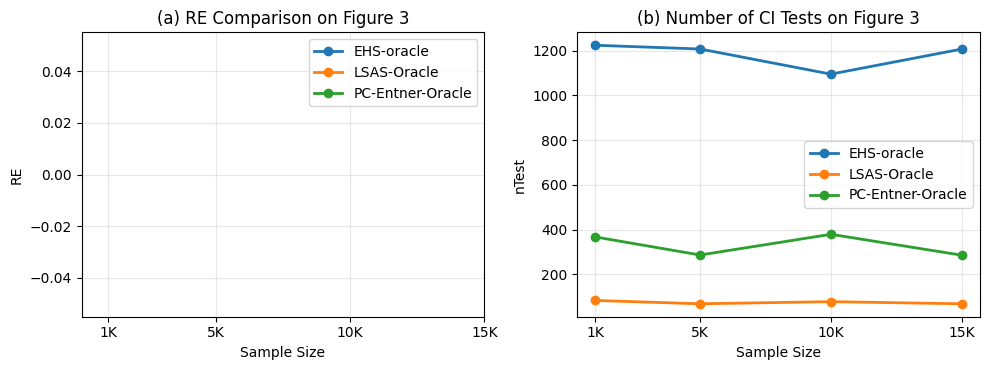

In [214]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

for method in summary["method"].unique():
    df_method = summary[summary["method"] == method]

    # RE panel
    axes[0].plot(
        df_method["sample_size"],
        df_method["mean_RE"],
        marker="o",
        linewidth=2,
        label=method
    )

    # nTest panel
    axes[1].plot(
        df_method["sample_size"],
        df_method["mean_nTest"],
        marker="o",
        linewidth=2,
        label=method
    )

axes[0].set_xlabel("Sample Size")
axes[0].set_ylabel("RE")
axes[0].set_title("(a) RE Comparison on Figure 3")
axes[0].set_xticks(sample_sizes)
axes[0].set_xticklabels(["1K", "5K", "10K", "15K"])
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set_xlabel("Sample Size")
axes[1].set_ylabel("nTest")
axes[1].set_title("(b) Number of CI Tests on Figure 3")
axes[1].set_xticks(sample_sizes)
axes[1].set_xticklabels(["1K", "5K", "10K", "15K"])
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()